In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import squidpy as sq
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.extend(['../../scripts','../../scripts/xenium'])
import coda
import readwrite
from plot_utils import (
    prepare_clustered_data,
    clustermap,
    barplot,
    stackplot
)
cfg = readwrite.config()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/__init__.py:44: F

### Params

In [16]:
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'CRC'
panel = 'all'

xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

xenium_levels = ['segmentation','condition','panel','donor','sample']
normalisation = 'lognorm'
reference = 'GEO_GSE178341' # 'GEO_GSE178341' GEO_GSE236581
method = 'rctd_class_aware'
level = 'Level1'

condition_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'condition_palette.csv',index_col=0).iloc[:,0].to_dict()
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0).iloc[:,0].to_dict()
gene_sets_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'gene_sets_palette.csv',index_col=0).iloc[:,0].to_dict()
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0).iloc[:,0].to_dict()

palettes = {
    "condition": condition_palette,
    "donor_corrected": donor_palette,
    "gene_sets": gene_sets_palette,
    "leiden_0.6_named": gene_sets_palette,
    "Donor": donor_palette,
    "donor": donor_palette,
    "Program": gene_sets_palette,
    "Level1": cell_type_palette,
    "Level1_with_programs": gene_sets_palette | cell_type_palette
}

# qc params
min_n_counts = 20

# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'

integration_method = 'bbknn'
run = 12

### Read all xenium samples

In [3]:
# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=[condition] if condition != 'all' else None,
    panels_filter=[panel] if panel != 'all' else None
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[correction_method])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(xenium_paths['raw'], anndata=True, pool_mode="thread", max_workers=6)

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# # remove 169V sample
# print("Exclude 169V peritoneal sample")
# ads['raw'] = { k:v for k,v in ads['raw'].items() if k[-2] != '169V' }

# concat samples
genes = [v.var_names for k, v in ads[correction_method].items()]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

adata = sc.concat({k: v for k, v in ads[correction_method].items()}, label="dataset_id", join="outer")[
    :, common_genes
].copy()


# create metadata, full cell identifiers
adata.obs[xenium_levels] = pd.DataFrame(adata.obs["dataset_id"].tolist(), index=adata.obs.index, columns=xenium_levels)
adata.obs["correction_method"] = correction_method
adata.obs['cell_id'] = 'proseg-' + adata.obs['cell_id'].astype(str)
adata.obs['full_id'] = adata.obs[['segmentation', 'condition', 'panel', 'donor', 'sample','cell_id']].agg('_'.join, axis=1)

# exclude bad QC cells creating leiden outlier after data integration
df_cells_to_exclude_leiden_outlier = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_leiden_outlier.csv",index_col=0)
adata = adata[~(adata.obs["full_id"].isin(df_cells_to_exclude_leiden_outlier["full_id"]))].copy()
print("Filtering out",len(df_cells_to_exclude_leiden_outlier),"cells creating outlier leiden cluster after integration")

# exclude healthy epithelial cells from 1DDI
idx_cells_to_exclude_1DDI = pd.read_csv(cfg['xenium_metadata_dir']+"malignant_cells_1DDI_tumor.csv",index_col=0).iloc[:,0].values
adata = adata[~(adata.obs["full_id"].isin(idx_cells_to_exclude_1DDI))].copy()
print("Filtering out",len(idx_cells_to_exclude_1DDI),"healthy epithelial cells from 1DDI")

# relabel epithelial cells with high CAF signature to stromal
idx_cells_to_exclude_malignant = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_from_malignant.csv",index_col=0).iloc[:,0].values
adata.obs.loc[adata.obs['full_id'].isin(idx_cells_to_exclude_malignant),level] = 'Strom'
print("Relabelling",len(idx_cells_to_exclude_malignant),"malignant cells to stromal cells")

# apply QC
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=False)
idx_qc = (adata.obs["total_counts"] > min_n_counts)
print('Filtering out',sum(~idx_qc),f'cells with less than {min_n_counts} counts')
adata = adata[idx_qc].copy()

# rename cell types
adata.obs[level] = adata.obs[level].replace({
    'Strom':'stromal cell',
    'Epi':'malignant cell',
    'B':'B cell',
    'Myeloid':'myeloid cell',
    'Plasma':'plasma cell',
    'Mast':'mast cell',
    'TNKILC':'lymphoid cell'
    })


# info about the loaded cohort
df_cohort_info = pd.DataFrame([k+(corr_method,) for corr_method in [correction_method] for k in ads[corr_method].keys() ], columns=xenium_levels+['correction_method'])

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:831: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

Error processing [Errno 2] No such file or directory: '/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/proseg/CRC/hImmune_v1_mm/169V/output-XETG00059__0032822__169V__20250811__161841/raw_results/experiment.xenium'


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdat

Filtering out 17796 cells creating outlier leiden cluster after integration


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 8810 healthy epithelial cells from 1DDI
Relabelling 23297 malignant cells to stromal cells
Filtering out 52829 cells with less than 20 counts


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# adata.obs.set_index('full_id')[['Level1']].to_parquet('../../scratch/adata_obs_CRC.parquet')

### Plot UMAP

In [45]:
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
# sc.pp.pca(adata)
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

for color in [level, 'donor']:
    p = Path(cfg['figures_dir']+f"xenium/coda/{correction_method}/{segmentation}/umap_CRC_{color}.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        adata.obs[color] = adata.obs[color].astype('category')
        adata.obs[color] = adata.obs[color].cat.reorder_categories(
            np.unique(adata.obs[color]), ordered=True
        )
        sc.pl.embedding(
            adata,
            'X_umap',
            color=color,
            show=False,
            s=.2,
            palette=palettes[color],
            title='',
            frameon=False,      # remove axis frame (Scanpy ≥1.9)
            legend_loc=None
        )

        fig = plt.gcf()
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

    else:
        print('Found file, skipping:',p)

Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/coda/raw/proseg_expected/umap_CRC_Level1.png
Found file, skipping: /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/figures/xenium/coda/raw/proseg_expected/umap_CRC_donor.png


In [40]:
custom_plot_orders = {
    level: ['stromal cell','malignant cell', 'myeloid cell',
            'plasma cell', 'lymphoid cell', 'B cell', 'mast cell'], 
}

for color in [level, 'donor']:
    p = Path(cfg['figures_dir']+f"xenium/coda/{correction_method}/{segmentation}/umap_CRC_{color}.png")
    p.parent.mkdir(parents=True, exist_ok=True)

    if True: # not p.exists():
        
        # 1. Prepare Data for Seaborn
        umap_coords = adata.obsm['X_umap']
        df_plot = pd.DataFrame({
            'UMAP1': umap_coords[:, 0],
            'UMAP2': umap_coords[:, 1],
            color: adata.obs[color].values
        })

        # 2. Determine Order
        if color in custom_plot_orders:
            order = custom_plot_orders[color]
            df_plot.sort_values(color, key=np.vectorize(order.index))
        else:
            order = None

        # 3. Plot
        fig, ax = plt.subplots(figsize=(6, 6))

        sns.scatterplot(
            data=df_plot,
            x='UMAP1',
            y='UMAP2',
            hue=color,
            hue_order=order, 
            palette=palettes[color], 
            s=.5,                       
            linewidth=0,               
            ax=ax,
            legend=False
        )
        ax.axis('off')                

        # Save
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

    else:
        print('Found file, skipping:', p)

### Read morphology, mutations metadata

In [4]:
path_morphology_classes = cfg['xenium_metadata_dir']+"combined_pdo_aug.csv"
path_mutations = cfg['xenium_metadata_dir']+"mut_long.csv"
path_clinical = cfg['xenium_metadata_dir']+"xenium_39_pdo_clinical_data.csv"

# read
df_mut = pd.read_csv(path_mutations,index_col=0)
df_clin = pd.read_csv(path_clinical)
df_morph_classes = pd.read_csv(path_morphology_classes,index_col='component_and_cluster_and_lasso')

# fix typos
donor_typos = {
    '1J2S':'1J25',
    '1B17':'1BI7',
    '0WJ3':'OWJ3',
    '0Y6H':'OY6H',
    '03F0':'03FO',
    '0UC4':'OUC4',
    '0WMY':'OWMY',
    '0YRI':'OYRI',
    '056A':'O056',
    '0UC1':'OUC1',
    '0AFN':'OAFN'
    }
df_mut['donor']=df_mut['Patient_ID'].replace(donor_typos)
df_clin['donor']=df_clin['Patient_ID'].replace(donor_typos)
df_morph_classes['donor']=df_morph_classes['donor'].replace({
    '0UC4':'OUC4', 
    '0UC1':'OUC1'
})

# reshape to wide
df_clin = pd.concat((
    df_mut.pivot(index='donor', columns='Gene', values='Status').astype('str'),
    df_mut[['donor','CMS','CRIS','MSI']].drop_duplicates().set_index('donor'),
    df_clin.set_index('donor')
    ),axis=1)

df_morph_classes_donor_props = (
    df_morph_classes.groupby('donor')['morphology_cluster_named']
    .value_counts(normalize=True).unstack(fill_value=0))

### Read malignant programs annotation

In [ ]:
level_with_programs = f'{level}_with_programs'
integration_method = 'bbknn'
programs_key = f'leiden_0.6_{integration_method}_named'

obs_malignant = pd.read_parquet(cfg['results_dir']+f'xenium/integration/{correction_method}/{segmentation}/adata_malignant_obs_{integration_method}_{run}.parquet')

adata.obs_names = adata.obs['full_id']
col = adata.obs[level].astype(str)
col.update(obs_malignant[programs_key])
adata.obs[level_with_programs] = col.astype('str')

# filter out cells that didnt pass QC based on common genes with CRC_PDO
adata = adata[adata.obs[level_with_programs]!='malignant cell'].copy()

## overall composition

In [26]:
adata.obs['sample']=adata.obs['sample'].astype(str)

for plot_annot in [level, level_with_programs]:

    # get proportions
    df_props = (
        adata.obs
        .groupby(xenium_levels)[plot_annot]
        .value_counts(normalize=True)
        .unstack()
        .reset_index()
    )
    df_props['full_sample_id'] = df_props[xenium_levels].astype(str).agg(' | '.join, axis=1)

    # plot
    num_samples = len(df_props.index)
    fig_height = max(6, num_samples * 0.4) 

    fig, ax = plt.subplots(figsize=(12, fig_height))
    df_props.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        width=0.8,
        color=palettes[plot_annot]
    )

    ax.set_xlabel('Proportion', fontsize=12)
    ax.set_ylabel('Sample', fontsize=12)
    ax.set_yticklabels(df_props['donor'])
    ax.legend(title=plot_annot, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_xlim(0, 1)
    plt.tight_layout()

    # save
    # df_props.to_csv(f'../../scratch/celltype_composition_{segmentation}_{reference}_{level}.csv')
    output_path = cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_composition_per_sample_{plot_annot}.png'
    p = Path(output_path)
    p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(p, dpi=300, bbox_inches='tight')
    plt.close(fig)

## niche analysis by MP for CRC

  0%|          | 0/1000 [00:00<?, ?/s]

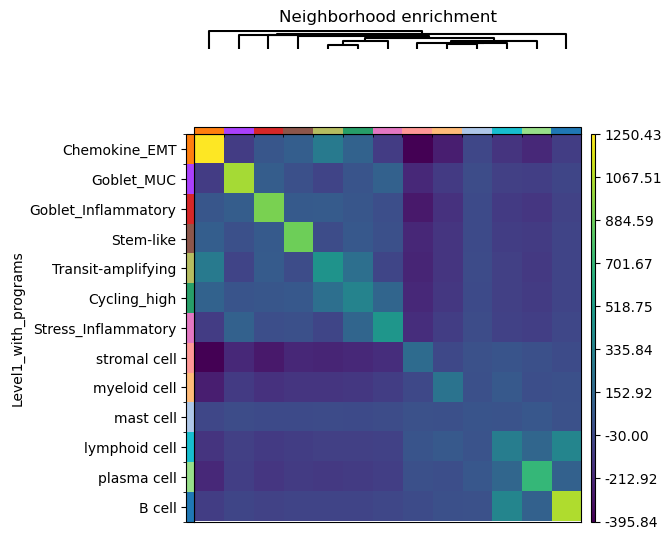

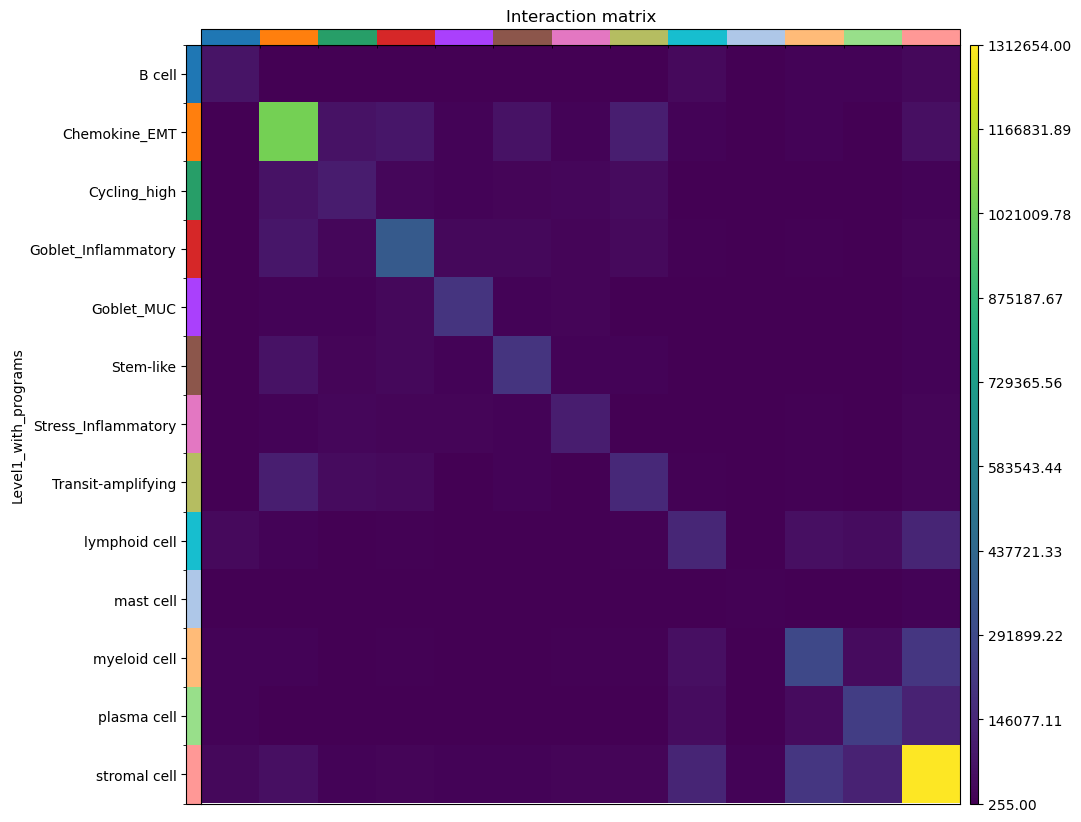

In [27]:
adata.obs['sample'] = adata.obs['sample'].astype('category')
adata.obs[level_with_programs] = adata.obs[level_with_programs].astype('category')

# enrichment for crc
sq.gr.spatial_neighbors(adata, radius=15, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)
sq.gr.nhood_enrichment(adata, cluster_key=level_with_programs)
sq.pl.nhood_enrichment(adata, cluster_key=level_with_programs, method="average", figsize=(5, 5))

sq.gr.interaction_matrix(adata, cluster_key=level_with_programs)
sq.pl.interaction_matrix(adata, cluster_key=level_with_programs)

## coda plots

In [6]:
adata.obs = adata.obs.join(df_clin,on='donor')
adata.obs = adata.obs.join(df_morph_classes_donor_props,on='donor')

adata.obs['sample']=adata.obs['sample'].astype('category')
sq.gr.spatial_neighbors(adata, radius=15, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)
knnidx,knndist = coda.sparse_to_knn(adata.obsp['spatial_connectivities'])

adata_ilr = coda.get_ilr(adata, knnidx=knnidx, label_key=level_with_programs)
df_comp = pd.DataFrame(adata_ilr.obsm['X_knnlabels'], index=adata_ilr.obs_names,columns=adata_ilr.uns['X_knnlabels_columns'])
df_comp.to_parquet('../../scratch/df_composition_CRC.parquet')

### clustermap

In [ ]:
n_clusters = 10
col_order = [
    'B cell', 'lymphoid cell', 'mast cell',
    'myeloid cell', 'plasma cell', 'stromal cell', 'Chemokine_EMT', 'Goblet_Inflammatory',
    'Goblet_MUC',  'Stress_Inflammatory', 'Transit-amplifying', 'Cycling_high', 'Stem-like',
]
malignant_columns = ['malignant cell','Goblet_MUC',  'Stress_Inflammatory', 'Transit-amplifying', 'Cycling_high', 'Stem-like']

for label_key in [level, level_with_programs]:
    adata_ilr = coda.get_ilr(adata, knnidx=knnidx, label_key=label_key)

    for exclude_all_malignant in [True, False]:
        for scale in [1,None]:

            print(label_key,scale,exclude_all_malignant)

            df_comp = pd.DataFrame(adata_ilr.obsm['X_composition'], columns=adata_ilr.uns['X_knnlabels_columns'])

            if label_key == level_with_programs:
                df_comp = df_comp[col_order]

            # prevent artificial donor cluster order
            perm = np.random.default_rng(0).permutation(len(df_comp))
            df_comp = df_comp.iloc[perm].reset_index(drop=True)
            
            annotations = dict(
                Donor = adata_ilr.obs['donor'].iloc[perm],
            )
            cmaps = dict(
                Site = 'Set2',
                Organ = 'Dark2'
            )

            df_ordered, annotations_ordered, clusters_ordered, cluster_order, palettes_ = prepare_clustered_data(
                df_comp=df_comp,
                annotations=annotations,
                n_clusters=n_clusters,
                exclude_all_malignant=exclude_all_malignant,
                malignant_columns=malignant_columns,
                cmaps=cmaps,
                n_micro_clusters=1000,
                metric='jensenshannon',
                method='average',
                force_positive=True
            )
            palettes_['Donor'] = palettes['Donor']
            palettes_['Cell type'] = palettes[label_key]

            # Clustermap
            legend_positions = {
                'Cluster': (0.02, 0.45),
                'Donor': (0.02, 0.22),

            }
            clustermap(
                df_comp_ordered=df_ordered,
                annotations_ordered=annotations_ordered,
                palettes=palettes_,
                legend_positions=legend_positions,
                figure_top_margin=0.8,
                colorbar_position=[0.02, 0.6, 0.05, 0.18], #[left, bottom, width, height]
                standard_scale=scale,
                output_path = cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_composition_clustermap_{label_key}_{exclude_all_malignant=}_{scale=}.png',
            )


        stackplot(
            df_comp_ordered=df_ordered,
            annotations_ordered=annotations_ordered,
            palettes=palettes_,
            grouping_col_name='Donor',
            proportions_palette_key='Cell type',
            output_path=cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_composition_niche_barplot_{label_key}_{exclude_all_malignant=}.png'
            )

        barplot(
            clusters_ordered,
            cluster_order,
            annotations_ordered,
            palettes_,
            grouping_col_name='Donor',
            output_path=cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_composition_donor_barplot_{label_key}_{exclude_all_malignant=}.png'
        )

Level1 1 True
Level1 None True
Level1 1 False
Level1 None False
Level1_with_programs 1 True
Level1_with_programs None True
Level1_with_programs 1 False
Level1_with_programs None False


In [33]:
# same thing but epi cells only
n_clusters=10

for label_key in [level, level_with_programs]:
    adata_ilr = coda.get_ilr(adata, knnidx=knnidx, label_key=label_key)
    adata_ilr_malignant = adata_ilr[adata_ilr.obs[level]=='malignant cell']

    for exclude_all_malignant in [True, False]:
        for scale in [1, None]:

            print(label_key,scale,exclude_all_malignant)

            df_comp = pd.DataFrame(adata_ilr_malignant.obsm['X_composition'], columns=adata_ilr_malignant.uns['X_knnlabels_columns'])

            if label_key == level_with_programs:
                df_comp = df_comp[col_order]

            # prevent artificial donor cluster order
            perm = np.random.default_rng(0).permutation(len(df_comp))
            df_comp = df_comp.iloc[perm].reset_index(drop=True)
            
            annotations = dict(
                Donor = adata_ilr.obs['donor'].iloc[perm],
            )
            cmaps = dict(
                Site = 'Set2',
                Organ = 'Dark2'
            )
            df_ordered, annotations_ordered, clusters_ordered, cluster_order, palettes_ = prepare_clustered_data(
                df_comp=df_comp,
                annotations=annotations,
                n_clusters=n_clusters,
                exclude_all_malignant=exclude_all_malignant,
                malignant_columns=malignant_columns,
                cmaps=cmaps,
                n_micro_clusters=1000,
                metric='jensenshannon',
                method='average',
                force_positive=True
            )
            palettes_['Donor'] = palettes['Donor']
            palettes_['Cell type'] = palettes[label_key]

            # Clustermap
            legend_positions = {
                'Cluster': (0.02, 0.45),
                'Donor': (0.02, 0.22),
            }
            
            clustermap(
                df_comp_ordered=df_ordered,
                annotations_ordered=annotations_ordered,
                palettes=palettes_,
                legend_positions=legend_positions,
                figure_top_margin=0.8,
                colorbar_position=[0.02, 0.6, 0.05, 0.18], #[left, bottom, width, height]
                standard_scale=scale,
            output_path = cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_malignant_composition_clustermap_{label_key}_{exclude_all_malignant=}_{scale=}.png',
            )

        stackplot(
            df_comp_ordered=df_ordered,
            annotations_ordered=annotations_ordered,
            palettes=palettes_,
            grouping_col_name='Donor',
            proportions_palette_key='Cell type',
            output_path=cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_malignant_composition_niche_barplot_{label_key}_{exclude_all_malignant=}.png'
            )

        barplot(
            clusters_ordered,
            cluster_order,
            annotations_ordered,
            palettes_,
            grouping_col_name='Donor',
            output_path=cfg['figures_dir'] + f'xenium/coda/{correction_method}/{segmentation}/CRC_malignant_composition_donor_barplot_{label_key}_{exclude_all_malignant=}.png'
        )

Level1 1 True
Level1 None True
Level1 1 False
Level1 None False
Level1_with_programs 1 True
Level1_with_programs None True
Level1_with_programs 1 False
Level1_with_programs None False
